# Trabajo Final — Fundamentos y Algoritmia para Inteligencia Artificial

**Caso práctico:** DataExpert — Análisis y desarrollo de algoritmos para IA con fundamento matemático.

**Dataset:** Seeds (UCI Machine Learning Repository). 210 semillas de trigo de tres variedades (Kama, Rosa y Canadian), descritas por 7 medidas geométricas del grano.

| Actividad | Tema |
|---|---|
| 1 | Carga y exploración con Pandas |
| 2 | Separación de variables y normalización |
| 3 | Álgebra lineal con NumPy |
| 4 | Estadística descriptiva de Area y Perimeter |
| 5 | Valores atípicos en Area |
| 6 | Histograma y gráfico de dispersión |
| 7 | Comparación de modelos: KNN vs. Árbol de Decisión |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier #(K VECINOS CERCANOS)
from sklearn.tree import DecisionTreeClassifier #(ÁRBOL DE DECISIÓN)

## 1. Carga y exploración del dataset

In [2]:
df = pd.read_csv('data/seeds_dataset.csv')
df.head()

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoeff,KernelGrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [3]:
print('Forma del dataset:', df.shape)   #210 filas, 8 columnas (7 características + Class)
print()
df.info()

Forma del dataset: (210, 8)

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Area                210 non-null    float64
 1   Perimeter           210 non-null    float64
 2   Compactness         210 non-null    float64
 3   KernelLength        210 non-null    float64
 4   KernelWidth         210 non-null    float64
 5   AsymmetryCoeff      210 non-null    float64
 6   KernelGrooveLength  210 non-null    float64
 7   Class               210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [4]:
caracteristicas = df.columns.drop('Class')
print('Cantidad de características:', len(caracteristicas))
print(list(caracteristicas))

Cantidad de características: 7
['Area', 'Perimeter', 'Compactness', 'KernelLength', 'KernelWidth', 'AsymmetryCoeff', 'KernelGrooveLength']


In [5]:
print('---VALORES NULOS POR COLUMNA---')
print(df.isnull().sum())
print('Total de valores nulos:', df.isnull().sum().sum())

---VALORES NULOS POR COLUMNA---
Area                  0
Perimeter             0
Compactness           0
KernelLength          0
KernelWidth           0
AsymmetryCoeff        0
KernelGrooveLength    0
Class                 0
dtype: int64
Total de valores nulos: 0


In [6]:
nombres = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}   #variedad de trigo de cada clase
print('---CANTIDAD POR VARIEDAD---')
print(df['Class'].map(nombres).value_counts())

---CANTIDAD POR VARIEDAD---
Class
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


In [7]:
df.describe().round(3)

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoeff,KernelGrooveLength,Class
count,210.000,210.000,210.000,210.000,210.000,210.000,210.000,210.000
mean,14.848,14.559,0.871,5.629,3.259,3.700,5.408,2.000
std,2.910,1.306,0.024,0.443,0.378,1.504,0.491,0.818
min,10.590,12.410,0.808,4.899,2.630,0.765,4.519,1.000
25%,12.270,13.450,0.857,5.262,2.944,2.562,5.045,1.000
50%,14.355,14.320,0.873,5.524,3.237,3.599,5.223,2.000
75%,17.305,15.715,0.888,5.980,3.562,4.769,5.877,3.000
max,21.180,17.250,0.918,6.675,4.033,8.456,6.550,3.000


## 2. Separación de variables y normalización

In [8]:
x = df.drop(columns='Class')   #características predictoras
y = df['Class']                #variable objetivo (variedad)
print('x:', x.shape)
print('y:', y.shape)

x: (210, 7)
y: (210,)


In [9]:
scaler = StandardScaler()
x_esc = scaler.fit_transform(x)   #cada columna queda con media 0 y desviación 1

print('Media antes de escalar:  ', x.mean().round(2).values)
print('Media después de escalar:', x_esc.mean(axis=0).round(2))
print('Desv. después de escalar:', x_esc.std(axis=0).round(2))

Media antes de escalar:   [14.85 14.56  0.87  5.63  3.26  3.7   5.41]
Media después de escalar: [-0.  0.  0. -0. -0. -0. -0.]
Desv. después de escalar: [1. 1. 1. 1. 1. 1. 1.]


## 3. Álgebra lineal con NumPy

In [10]:
#VECTORES: cada semilla es un vector de 7 medidas
v1 = x.iloc[0].to_numpy()     #semilla 0 (Kama)
v2 = x.iloc[70].to_numpy()    #semilla 70 (Rosa)
print('v1:', v1)
print('v2:', v2)
print('Suma:  ', np.round(v1 + v2, 3))
print('Resta: ', np.round(v1 - v2, 3))

v1: [15.26  14.84   0.871  5.763  3.312  2.221  5.22 ]
v2: [17.63   15.98    0.8673  6.191   3.561   4.076   6.06  ]
Suma:   [32.89  30.82   1.738 11.954  6.873  6.297 11.28 ]
Resta:  [-2.37  -1.14   0.004 -0.428 -0.249 -1.855 -0.84 ]


In [11]:
#PRODUCTO PUNTO Y NORMA
print('Producto punto v1·v2:', round(np.dot(v1, v2), 3))
print('Norma de v1:', round(np.linalg.norm(v1), 3))
print('Norma de v2:', round(np.linalg.norm(v2), 3))
print('Distancia entre semillas ||v1 - v2||:', round(np.linalg.norm(v1 - v2), 3))  #lo que usa KNN para comparar

Producto punto v1·v2: 595.091
Norma de v1: 23.026
Norma de v2: 25.909
Distancia entre semillas ||v1 - v2||: 3.363


In [12]:
#MATRICES
M = x.to_numpy()   #matriz de datos (210 x 7)
print('Forma de M:', M.shape)
print('Forma de la transpuesta:', M.T.shape)
G = M.T @ M        #multiplicación matricial (7x210)·(210x7) = (7x7)
print('Forma de M.T @ M:', G.shape)

Forma de M: (210, 7)
Forma de la transpuesta: (7, 210)
Forma de M.T @ M: (7, 7)


In [13]:
#SISTEMA DE ECUACIONES: Perimeter = a·Area + b
#con dos semillas se arma un sistema de 2 ecuaciones y 2 incógnitas
area1, per1 = df.loc[0, 'Area'], df.loc[0, 'Perimeter']
area2, per2 = df.loc[70, 'Area'], df.loc[70, 'Perimeter']

A = np.array([[area1, 1],
              [area2, 1]])
B = np.array([per1, per2])

solucion = np.linalg.solve(A, B)
print('a =', round(solucion[0], 4))
print('b =', round(solucion[1], 4))
print('Comprobación A·solución =', np.round(A @ solucion, 3), ' B =', B)

a = 0.481
b = 7.4997
Comprobación A·solución = [14.84 15.98]  B = [14.84 15.98]


In [14]:
#Usando el mismo modelo para estimar el perímetro de otra semilla
area_nueva = df.loc[140, 'Area']
per_estimado = solucion[0] * area_nueva + solucion[1]
print('Area:', area_nueva)
print('Perímetro estimado:', round(per_estimado, 3))
print('Perímetro real:    ', df.loc[140, 'Perimeter'])

Area: 13.07
Perímetro estimado: 13.787
Perímetro real:     13.92


## 4. Estadística descriptiva de Area y Perimeter

In [15]:
for col in ['Area', 'Perimeter']:
    datos = df[col].to_numpy()
    print(f'---{col}---')
    print('Media:   ', round(np.mean(datos), 4))
    print('Mediana: ', round(np.median(datos), 4))
    print('Varianza:', round(np.var(datos), 4))
    print('Desv. estándar:', round(np.std(datos), 4))
    print()

---Area---
Media:    14.8475
Mediana:  14.355
Varianza: 8.426
Desv. estándar: 2.9028

---Perimeter---
Media:    14.5593
Mediana:  14.32
Varianza: 1.6974
Desv. estándar: 1.3028



In [16]:
#IMPLEMENTACIÓN MANUAL (poblacional: se divide entre n, igual que np.var)
def varianza_manual(datos):
    n = len(datos)
    media = sum(datos) / n
    suma_cuadrados = 0
    for valor in datos:
        suma_cuadrados += (valor - media) ** 2
    return suma_cuadrados / n

def desviacion_manual(datos):
    return varianza_manual(datos) ** 0.5

In [17]:
area = df['Area'].to_numpy()
var_m, desv_m = varianza_manual(area), desviacion_manual(area)
var_np, desv_np = np.var(area), np.std(area)

print('Varianza manual:', round(var_m, 6), '| NumPy:', round(var_np, 6))
print('Desviación manual:', round(desv_m, 6), '| NumPy:', round(desv_np, 6))
print('¿Coinciden?', np.isclose(var_m, var_np) and np.isclose(desv_m, desv_np))

Varianza manual: 8.426035 | NumPy: 8.426035
Desviación manual: 2.902763 | NumPy: 2.902763
¿Coinciden? True


In [18]:
#OJO: pandas usa varianza muestral (divide entre n-1)
print('pandas .var():', round(df['Area'].var(), 6))
print('np.var(ddof=1):', round(np.var(area, ddof=1), 6))

pandas .var(): 8.466351
np.var(ddof=1): 8.466351


## 5. Valores atípicos en Area (criterio de 2 desviaciones estándar)

In [19]:
media_area = np.mean(area)
desv_area = np.std(area)
lim_inf = media_area - 2 * desv_area
lim_sup = media_area + 2 * desv_area
print('Límite inferior:', round(lim_inf, 3))
print('Límite superior:', round(lim_sup, 3))

atipicos = df[(df['Area'] < lim_inf) | (df['Area'] > lim_sup)]
print('Cantidad de valores atípicos:', len(atipicos))
atipicos.assign(Variedad=atipicos['Class'].map(nombres))[['Area', 'Perimeter', 'Variedad']]

Límite inferior: 9.042
Límite superior: 20.653
Cantidad de valores atípicos: 4


,Area,Perimeter,Variedad
77,20.71,17.23,Rosa
88,21.18,17.21,Rosa
89,20.88,17.05,Rosa
114,20.97,17.25,Rosa


## 6. Visualización

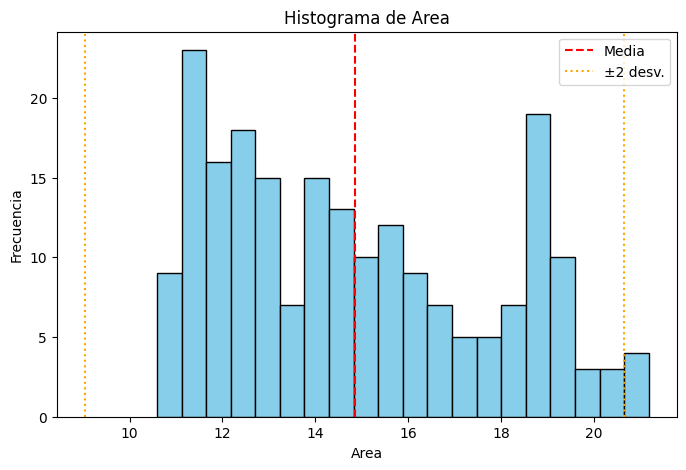

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df['Area'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(media_area, color='red', linestyle='--', label='Media')
plt.axvline(lim_inf, color='orange', linestyle=':', label='±2 desv.')
plt.axvline(lim_sup, color='orange', linestyle=':')
plt.title('Histograma de Area')
plt.xlabel('Area')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('graficos/histograma_area.png', dpi=150, bbox_inches='tight')
plt.show()

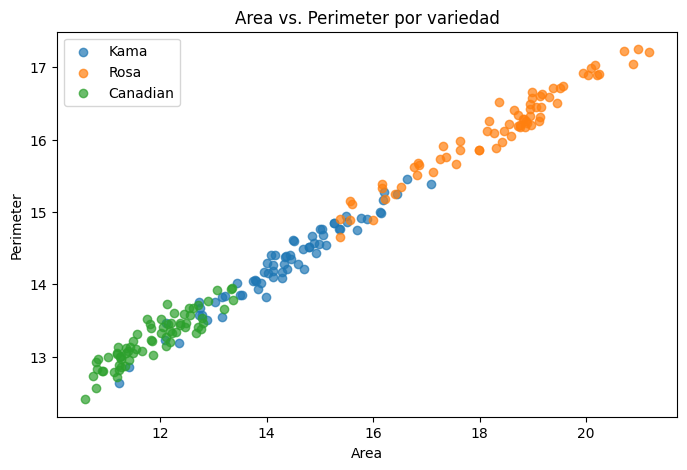

In [21]:
plt.figure(figsize=(8, 5))
for clase, color in zip([1, 2, 3], ['tab:blue', 'tab:orange', 'tab:green']):
    sub = df[df['Class'] == clase]
    plt.scatter(sub['Area'], sub['Perimeter'], color=color, label=nombres[clase], alpha=0.7)
plt.title('Area vs. Perimeter por variedad')
plt.xlabel('Area')
plt.ylabel('Perimeter')
plt.legend()
plt.savefig('graficos/dispersion_area_perimeter.png', dpi=150, bbox_inches='tight')
plt.show()

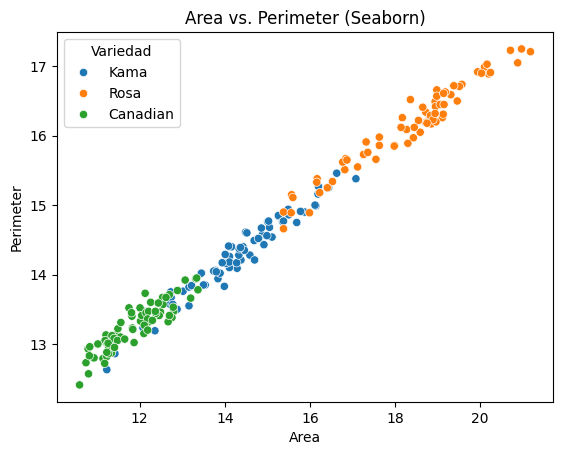

In [22]:
#Mismo gráfico con Seaborn
sns.scatterplot(data=df.assign(Variedad=df['Class'].map(nombres)),
                x='Area', y='Perimeter', hue='Variedad')
plt.title('Area vs. Perimeter (Seaborn)')
plt.show()

## 7. Comparación de modelos: KNN vs. Árbol de Decisión

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)   #fit solo con train
x_test = scaler.transform(x_test)
print('Entrenamiento:', x_train.shape, '| Prueba:', x_test.shape)

Entrenamiento: (168, 7) | Prueba: (42, 7)


In [24]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)
y_pred_knn = model_knn.predict(x_test)

print('---KNN---')
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=['Kama', 'Rosa', 'Canadian']))

---KNN---
Accuracy: 0.9047619047619048
              precision    recall  f1-score   support

        Kama       1.00      0.71      0.83        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



In [25]:
model_arbol = DecisionTreeClassifier(random_state=42)
model_arbol.fit(x_train, y_train)
y_pred_arbol = model_arbol.predict(x_test)

print('---ÁRBOL DE DECISIÓN---')
print('Accuracy:', accuracy_score(y_test, y_pred_arbol))
print(classification_report(y_test, y_pred_arbol, target_names=['Kama', 'Rosa', 'Canadian']))

---ÁRBOL DE DECISIÓN---
Accuracy: 0.8809523809523809
              precision    recall  f1-score   support

        Kama       0.91      0.71      0.80        14
        Rosa       0.87      0.93      0.90        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



KNN:               90.48%
Árbol de decisión: 88.10%


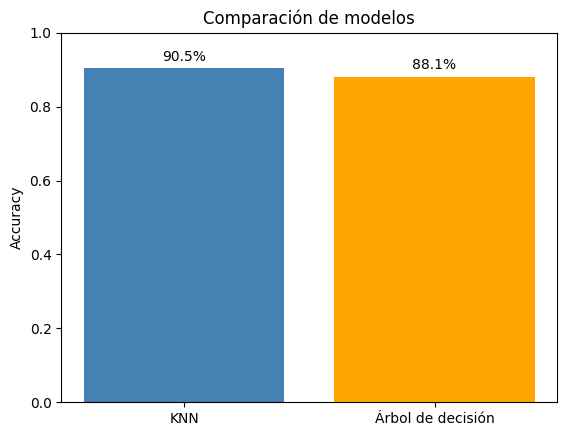

In [26]:
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_arbol = accuracy_score(y_test, y_pred_arbol)

print(f'KNN:               {acc_knn*100:.2f}%')
print(f'Árbol de decisión: {acc_arbol*100:.2f}%')

plt.bar(['KNN', 'Árbol de decisión'], [acc_knn, acc_arbol], color=['steelblue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparación de modelos')
for i, v in enumerate([acc_knn, acc_arbol]):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center')
plt.savefig('graficos/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
#PREDICCIÓN DE UNA SEMILLA DEL CONJUNTO DE PRUEBA
idx = 0
muestra = x_test[idx].reshape(1, -1)
real = np.asarray(y_test)[idx]
print('Real: ', nombres[real])
print('KNN:  ', nombres[model_knn.predict(muestra)[0]])
print('Árbol:', nombres[model_arbol.predict(muestra)[0]])

Real:  Kama
KNN:   Kama
Árbol: Kama


## Conclusiones

- El dataset Seeds no tiene valores nulos y sus tres variedades están balanceadas (70 semillas cada una), por lo que no fue necesario limpiar ni balancear datos.
- Las 7 características tienen escalas muy distintas; con StandardScaler todas quedan con media 0 y desviación 1, lo que es necesario para KNN porque compara distancias.
- El producto punto, la norma y la distancia entre vectores son la base de cómo KNN mide qué tan parecidas son dos semillas.
- La implementación manual de la varianza y la desviación estándar coincide con NumPy cuando ambas usan la misma fórmula (división entre n). Pandas usa n-1 por defecto.
- El gráfico de dispersión muestra que Area y Perimeter separan bien las variedades: Rosa tiene los granos más grandes, Canadian los más pequeños y Kama queda en medio.
- Los 4 valores atípicos de Area son semillas Rosa muy grandes (más de 20.65). No son errores de medición sino la variación natural de la variedad más grande, por eso se mantienen en el dataset.
- KNN obtuvo 90.48 % de accuracy y el Árbol de Decisión 88.10 %. Con 42 semillas de prueba la diferencia es de una sola semilla, así que ambos modelos rinden de forma parecida; KNN gana levemente porque las variedades forman grupos bien definidos en el espacio de características.
- En los dos modelos la variedad más difícil es Kama (recall 0.71), porque sus medidas quedan entre las de Rosa y Canadian y se confunde con ellas.